In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns",None)

Path("../data/processed").mkdir(parents=True, exist_ok =True)
Path("../dashboard/screenshots").mkdir(parents=True, exist_ok=True)

print("Setup Complete")

Setup Complete


In [6]:
raw_data_path = Path("../data/raw")

files = list(raw_data_path.glob("*"))

for file in files:
    print(file.name)

.ipynb_checkpoints
online_retail_II.xlsx


In [8]:
excel_files = list(raw_data_path.glob("*.xlsx"))


file_path = excel_files[0]
file_path

WindowsPath('../data/raw/online_retail_II.xlsx')

In [9]:
excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [19]:
sheet_names = excel_file.sheet_names


sheet_to_load = sheet_names[-1]

df = pd.read_excel(file_path, sheet_name=sheet_to_load)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [21]:
df.shape


(541910, 8)

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Missing Values Checked

In [23]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [24]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


### Data Cleaning

In [28]:
retail = df.copy()

# Remove rows without Customer ID
retail = retail.dropna(subset=["Customer ID"])

# Remove cancelled invoices
retail = retail[~retail["Invoice"].astype(str).str.startswith("C")]

# Remove negative or zero quantities
retail = retail[retail["Quantity"] > 0]

# Remove zero or negative prices
retail = retail[retail["Price"] > 0]

# Convert Customer ID to string
retail["Customer ID"] = retail["Customer ID"].astype(int).astype(str)

# Ensure InvoiceDate is datetime
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])

# Create Revenue column
retail["Revenue"] = retail["Quantity"] * retail["Price"]

retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Compare Before and After Cleaning

In [29]:
print("Original rows:", df.shape[0])
print("Cleaned rows:", retail.shape[0])
print("Rows removed:", df.shape[0] - retail.shape[0])
print("Remaining missing values:")
print(retail.isnull().sum())

Original rows: 541910
Cleaned rows: 397885
Rows removed: 144025
Remaining missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


In [30]:
retail.to_csv("../data/processed/cleaned_online_retail.csv", index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.


### Creating Main KPIS

In [31]:
total_revenue = retail["Revenue"].sum()
total_orders = retail["Invoice"].nunique()
total_customers = retail["Customer ID"].nunique()
total_products = retail["StockCode"].nunique()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")

Total Revenue: £8,911,425.90
Total Orders: 18,532
Total Customers: 4,338
Total Products: 3,665


### Monthly Revenue Analysis

In [32]:
retail["Month"] = retail["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = (
    retail.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,Month,Revenue
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361
5,2011-05,678594.560
6,2011-06,661213.690
7,2011-07,600091.011
8,2011-08,645343.900
9,2011-09,952838.382


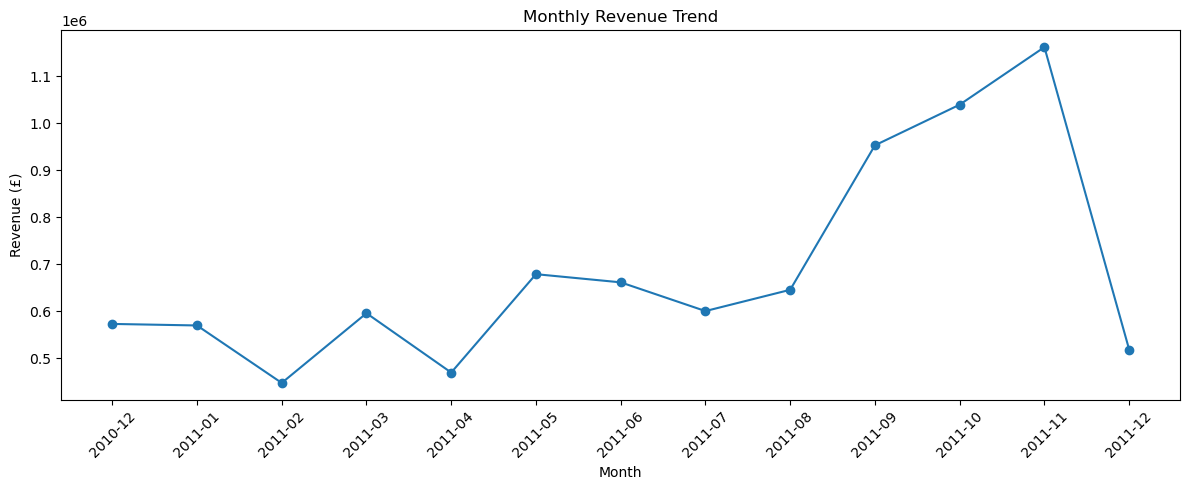

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["Month"], monthly_revenue["Revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dashboard/screenshots/monthly_revenue_trend.png", dpi=300)
plt.show()

### Top 10 Countries by Revenue

In [34]:
top_countries = (
    retail.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_countries

,Country,Revenue
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209042.050
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38378.330


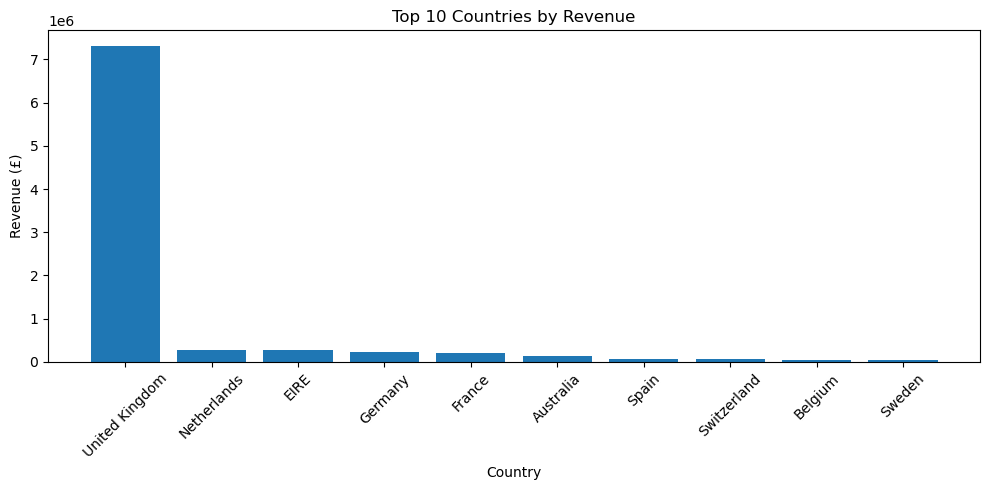

In [35]:
plt.figure(figsize=(10, 5))
plt.bar(top_countries["Country"], top_countries["Revenue"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dashboard/screenshots/top_countries_revenue.png", dpi=300)
plt.show()

### Top 10 Products by Revenue

In [36]:
top_products = (
    retail.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,Description,Revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142592.95
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,JUMBO BAG RED RETROSPOT,85220.78
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77821.96
6,PARTY BUNTING,68844.33
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,Manual,53779.93
9,RABBIT NIGHT LIGHT,51346.20


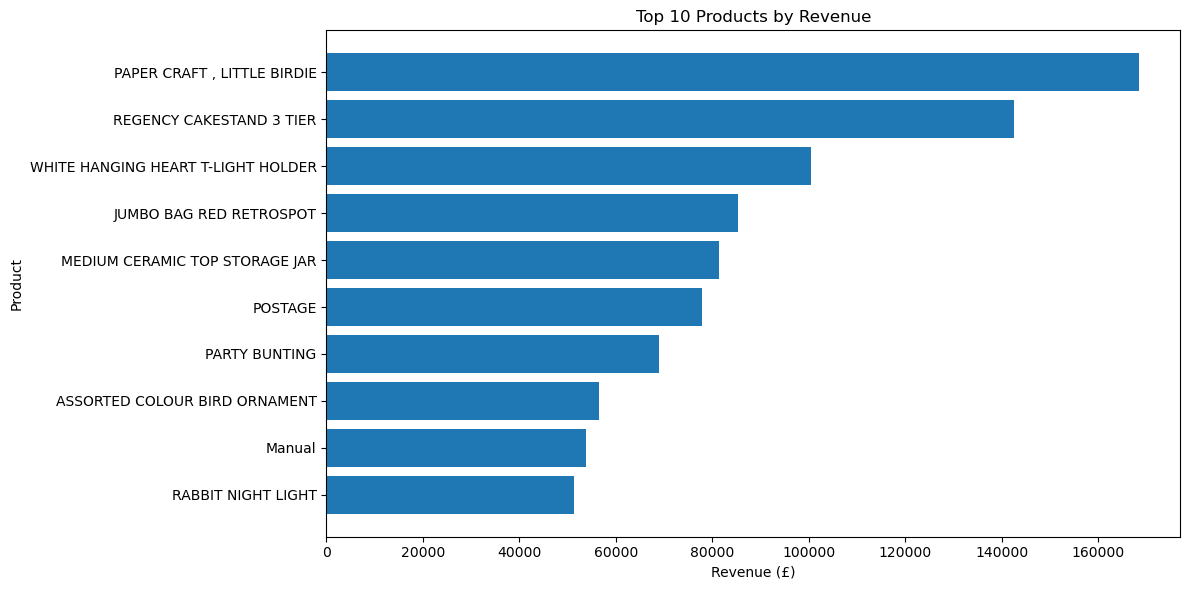

In [37]:
plt.figure(figsize=(12, 6))
plt.barh(top_products["Description"][::-1], top_products["Revenue"][::-1])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../dashboard/screenshots/top_products_revenue.png", dpi=300)
plt.show()

### Top 10 Customers by Revenue

In [38]:
top_customers = (
    retail.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers

,Customer ID,Revenue
0,14646,280206.02
1,18102,259657.30
2,17450,194550.79
3,16446,168472.50
4,14911,143825.06
5,12415,124914.53
6,14156,117379.63
7,17511,91062.38
8,16029,81024.84
9,12346,77183.60


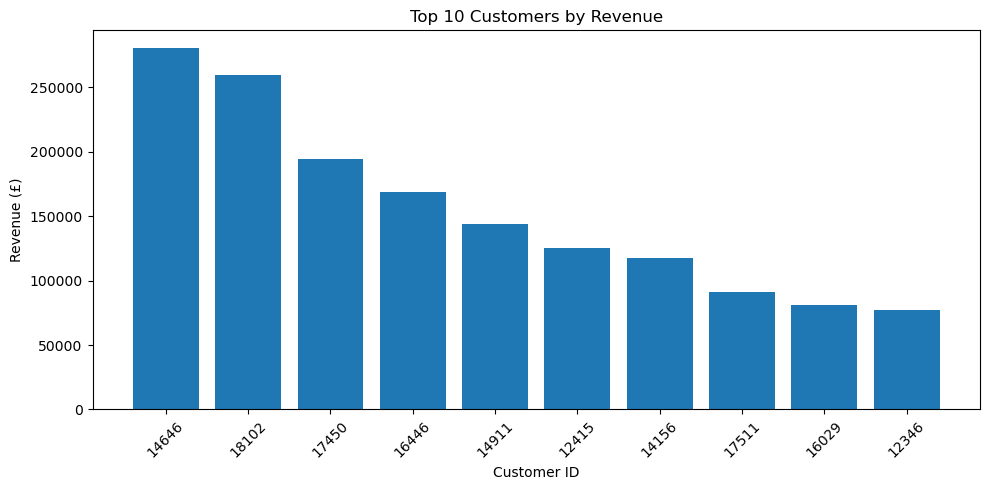

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(top_customers["Customer ID"], top_customers["Revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dashboard/screenshots/top_customers_revenue.png", dpi=300)
plt.show()

### Create RFM Table

In [40]:
snapshot_date = retail["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = retail.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["Customer ID", "Recency", "Frequency", "Monetary"]

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### Create RFM Scores

In [41]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,4,114
1,12347,2,7,4310.00,4,4,4,444
2,12348,75,4,1797.24,2,3,4,234
3,12349,19,1,1757.55,3,1,4,314
4,12350,310,1,334.40,1,1,2,112


### Create Customer Segments

In [42]:
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 2 and m >= 2:
        return "Loyal Customers"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r == 1 and f <= 2:
        return "Lost Customers"
    elif m >= 3 and f <= 2:
        return "Big Spenders"
    else:
        return "Regular Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,4,114,Lost Customers
1,12347,2,7,4310.00,4,4,4,444,Champions
2,12348,75,4,1797.24,2,3,4,234,At Risk
3,12349,19,1,1757.55,3,1,4,314,Big Spenders
4,12350,310,1,334.40,1,1,2,112,Lost Customers


### Check Segment counts

In [43]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customer_Count=("Customer ID", "count"),
        Average_Recency=("Recency", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Monetary=("Monetary", "mean")
    )
    .reset_index()
    .sort_values("Customer_Count", ascending=False)
)

segment_summary

,Segment,Customer_Count,Average_Recency,Average_Frequency,Average_Monetary
2,Champions,1319,17.094769,9.376801,4932.949197
5,Regular Customers,1058,73.729679,1.603970,308.058423
3,Lost Customers,903,254.872647,1.208195,482.726369
0,At Risk,448,106.069196,4.685268,2136.950647
4,Loyal Customers,442,23.183258,2.323529,1066.649706
1,Big Spenders,168,77.101190,1.488095,1275.149583


In [44]:
rfm.to_csv("../data/processed/customer_segments.csv", index=False)
segment_summary.to_csv("../data/processed/segment_summary.csv", index=False)

print("Customer segmentation files saved.")

Customer segmentation files saved.


### Create Customer Segment Chart

In [47]:
segment_counts = rfm["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Customer Count"]

segment_counts

,Segment,Customer Count
0,Champions,1319
1,Regular Customers,1058
2,Lost Customers,903
3,At Risk,448
4,Loyal Customers,442
5,Big Spenders,168


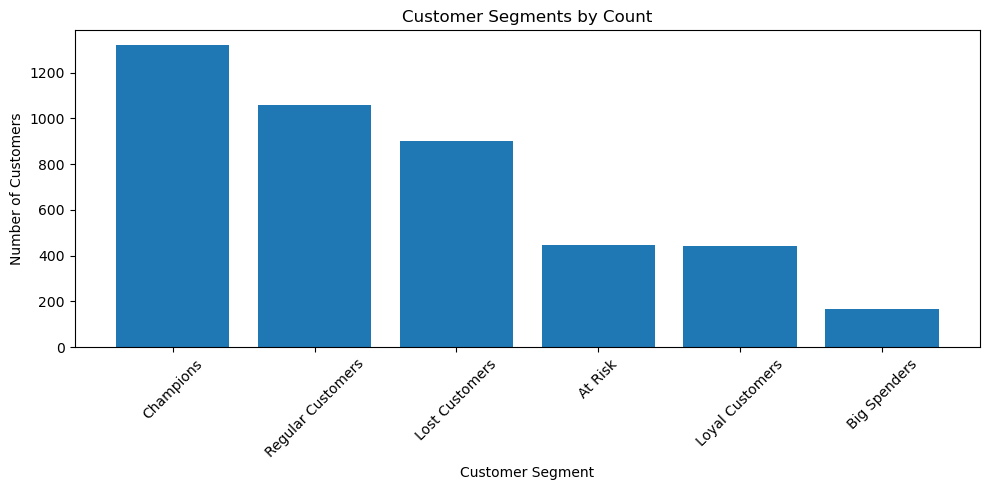

In [48]:
plt.figure(figsize=(10, 5))
plt.bar(segment_counts["Segment"], segment_counts["Customer Count"])
plt.title("Customer Segments by Count")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dashboard/screenshots/customer_segments.png", dpi=300)
plt.show()

### Revenue by Segment

In [49]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue

,Segment,Monetary
0,Champions,6506559.991
1,At Risk,957353.890
2,Loyal Customers,471459.170
3,Lost Customers,435901.911
4,Regular Customers,325925.812
5,Big Spenders,214225.130


### Customer Segment Strategy

In [50]:
segment_strategy = pd.DataFrame({
    "Segment": [
        "Champions",
        "Loyal Customers",
        "Big Spenders",
        "At Risk",
        "Lost Customers",
        "Regular Customers"
    ],
    "Meaning": [
        "Recent, frequent and high-spending customers",
        "Recent customers with good purchase frequency/value",
        "Customers who spend highly but do not buy often",
        "Previously valuable customers who have not purchased recently",
        "Inactive customers with low recent engagement",
        "Average customers with moderate behaviour"
    ],
    "Recommended Action": [
        "Reward with loyalty perks, early product access and referral campaigns",
        "Encourage repeat purchases with personalised offers",
        "Target with premium bundles and limited-time offers",
        "Send win-back campaigns before they fully churn",
        "Use reactivation campaigns or low-cost email marketing",
        "Nurture with product recommendations and small incentives"
    ]
})

segment_strategy

,Segment,Meaning,Recommended Action
0,Champions,"Recent, frequent and high-spending customers","Reward with loyalty perks, early product acces..."
1,Loyal Customers,Recent customers with good purchase frequency/...,Encourage repeat purchases with personalised o...
2,Big Spenders,Customers who spend highly but do not buy often,Target with premium bundles and limited-time o...
3,At Risk,Previously valuable customers who have not pur...,Send win-back campaigns before they fully churn
4,Lost Customers,Inactive customers with low recent engagement,Use reactivation campaigns or low-cost email m...
5,Regular Customers,Average customers with moderate behaviour,Nurture with product recommendations and small...


In [51]:
segment_strategy.to_csv("../data/processed/segment_strategy.csv", index=False)

### Product ABC Analysis

In [52]:
product_revenue = (
    retail.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_revenue["Revenue_Percentage"] = product_revenue["Revenue"] / product_revenue["Revenue"].sum()
product_revenue["Cumulative_Percentage"] = product_revenue["Revenue_Percentage"].cumsum()

def abc_category(cumulative_percentage):
    if cumulative_percentage <= 0.80:
        return "A - High Value"
    elif cumulative_percentage <= 0.95:
        return "B - Medium Value"
    else:
        return "C - Low Value"

product_revenue["ABC_Category"] = product_revenue["Cumulative_Percentage"].apply(abc_category)

product_revenue.head(20)

,Description,Revenue,Revenue_Percentage,Cumulative_Percentage,ABC_Category
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,0.018905,0.018905,A - High Value
1,REGENCY CAKESTAND 3 TIER,142592.95,0.016001,0.034906,A - High Value
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,0.011272,0.046178,A - High Value
3,JUMBO BAG RED RETROSPOT,85220.78,0.009563,0.055741,A - High Value
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,0.009136,0.064877,A - High Value
5,POSTAGE,77821.96,0.008733,0.073610,A - High Value
6,PARTY BUNTING,68844.33,0.007725,0.081335,A - High Value
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34,0.006349,0.087685,A - High Value
8,Manual,53779.93,0.006035,0.093720,A - High Value
9,RABBIT NIGHT LIGHT,51346.20,0.005762,0.099481,A - High Value


In [53]:
product_revenue.to_csv("../data/processed/product_abc_analysis.csv", index=False)

In [54]:
abc_summary = product_revenue.groupby("ABC_Category").agg(
    Product_Count=("Description", "count"),
    Total_Revenue=("Revenue", "sum")
).reset_index()

abc_summary

,ABC_Category,Product_Count,Total_Revenue
0,A - High Value,810,7127784.780
1,B - Medium Value,959,1337748.670
2,C - Low Value,2108,445892.454


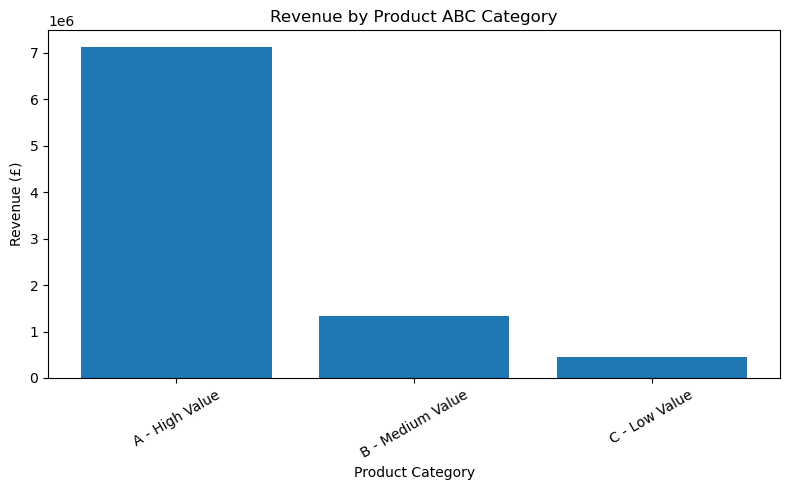

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(abc_summary["ABC_Category"], abc_summary["Total_Revenue"])
plt.title("Revenue by Product ABC Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../dashboard/screenshots/product_abc_revenue.png", dpi=300)
plt.show()

### Customer Value Concentration

In [56]:
customer_value = (
    rfm[["Customer ID", "Monetary"]]
    .sort_values("Monetary", ascending=False)
    .reset_index(drop=True)
)

customer_value["Customer_Rank"] = customer_value.index + 1
customer_value["Cumulative_Revenue"] = customer_value["Monetary"].cumsum()
customer_value["Cumulative_Revenue_Percentage"] = (
    customer_value["Cumulative_Revenue"] / customer_value["Monetary"].sum()
)

customer_value.head(10)

,Customer ID,Monetary,Customer_Rank,Cumulative_Revenue,Cumulative_Revenue_Percentage
0,14646,280206.02,1,280206.02,0.031443
1,18102,259657.30,2,539863.32,0.060581
2,17450,194550.79,3,734414.11,0.082413
3,16446,168472.50,4,902886.61,0.101318
4,14911,143825.06,5,1046711.67,0.117457
5,12415,124914.53,6,1171626.20,0.131475
6,14156,117379.63,7,1289005.83,0.144646
7,17511,91062.38,8,1380068.21,0.154865
8,16029,81024.84,9,1461093.05,0.163957
9,12346,77183.60,10,1538276.65,0.172618


In [57]:
top_10_percent_count = int(len(customer_value) * 0.10)

top_10_revenue = customer_value.head(top_10_percent_count)["Monetary"].sum()
total_customer_revenue = customer_value["Monetary"].sum()

top_10_revenue_share = top_10_revenue / total_customer_revenue

print(f"Top 10% customers: {top_10_percent_count}")
print(f"Top 10% revenue share: {top_10_revenue_share:.2%}")

Top 10% customers: 433
Top 10% revenue share: 61.33%


In [58]:
customer_value.to_csv("../data/processed/customer_value_concentration.csv", index=False)

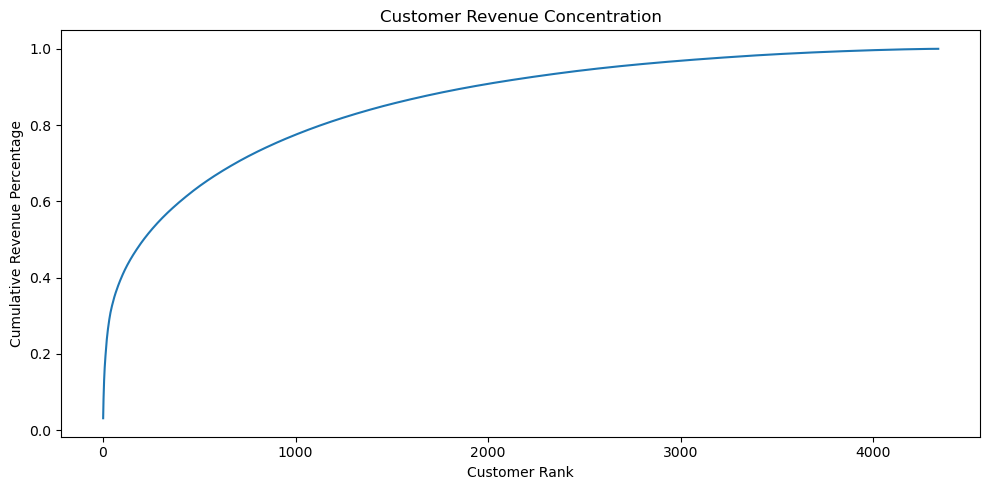

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(customer_value["Customer_Rank"], customer_value["Cumulative_Revenue_Percentage"])
plt.title("Customer Revenue Concentration")
plt.xlabel("Customer Rank")
plt.ylabel("Cumulative Revenue Percentage")
plt.tight_layout()
plt.savefig("../dashboard/screenshots/customer_revenue_concentration.png", dpi=300)
plt.show()

### Cohort Retention Analysis

In [60]:
retail["InvoiceMonth"] = retail["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

retail["CohortMonth"] = retail.groupby("Customer ID")["InvoiceMonth"].transform("min")

def get_month_difference(row):
    invoice_year = row["InvoiceMonth"].year
    invoice_month = row["InvoiceMonth"].month
    cohort_year = row["CohortMonth"].year
    cohort_month = row["CohortMonth"].month

    return (invoice_year - cohort_year) * 12 + (invoice_month - cohort_month) + 1

retail["CohortIndex"] = retail.apply(get_month_difference, axis=1)

cohort_data = (
    retail.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customer ID"
)

cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_sizes, axis=0)

retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


In [61]:
retention.to_csv("../data/processed/cohort_retention.csv")

In [62]:
average_retention = retention.mean().reset_index()
average_retention.columns = ["Cohort Month Number", "Average Retention Rate"]

average_retention

,Cohort Month Number,Average Retention Rate
0,1,1.000000
1,2,0.206232
2,3,0.221163
3,4,0.232444
4,5,0.245546
5,6,0.250812
6,7,0.243691
7,8,0.242578
8,9,0.250579
9,10,0.278291


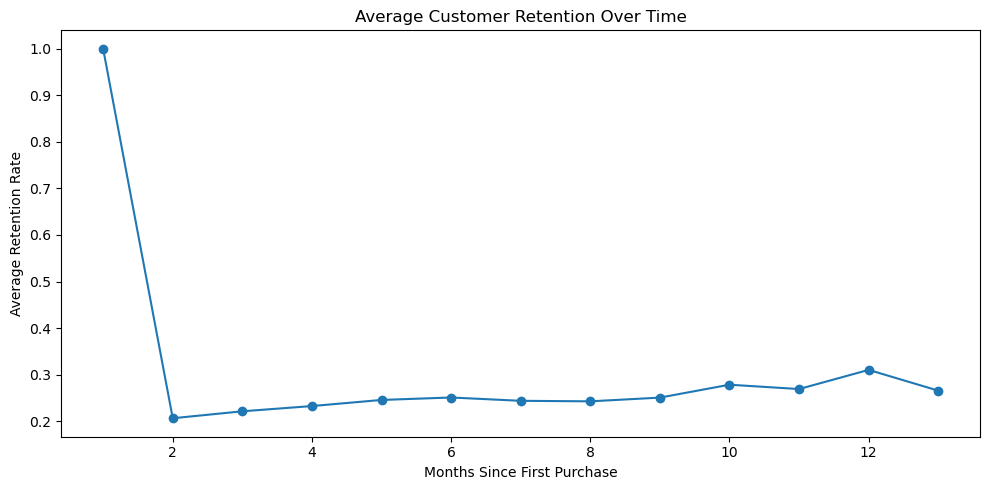

In [63]:
plt.figure(figsize=(10, 5))
plt.plot(
    average_retention["Cohort Month Number"],
    average_retention["Average Retention Rate"],
    marker="o"
)
plt.title("Average Customer Retention Over Time")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention Rate")
plt.tight_layout()
plt.savefig("../dashboard/screenshots/average_customer_retention.png", dpi=300)
plt.show()

### Bought-Together Product Analysis

In [67]:
from itertools import combinations

# Get top 20 products by revenue
top_20_products = (
    retail.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

# Keep only rows with those top products
basket_data = retail[retail["Description"].isin(top_20_products)]

# Group products by invoice
invoice_products = (
    basket_data.groupby("Invoice")["Description"]
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)

# Create product pair counts
pair_counts = {}

for products in invoice_products["Description"]:
    for pair in combinations(products, 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

# Convert to DataFrame
product_pairs = pd.DataFrame(
    [
        {
            "Product 1": pair[0],
            "Product 2": pair[1],
            "Times Bought Together": count
        }
        for pair, count in pair_counts.items()
    ]
)

# Sort by most frequently bought together
product_pairs = product_pairs.sort_values(
    "Times Bought Together",
    ascending=False
)

product_pairs.head(10)

,Product 1,Product 2,Times Bought Together
9,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546
94,PARTY BUNTING,SPOTTY BUNTING,389
50,PARTY BUNTING,WHITE HANGING HEART T-LIGHT HOLDER,279
14,ASSORTED COLOUR BIRD ORNAMENT,WHITE HANGING HEART T-LIGHT HOLDER,271
2,JUMBO BAG RED RETROSPOT,WHITE HANGING HEART T-LIGHT HOLDER,251
55,JAM MAKING SET WITH JARS,SET OF 3 CAKE TINS PANTRY DESIGN,242
15,REGENCY CAKESTAND 3 TIER,WHITE HANGING HEART T-LIGHT HOLDER,234
13,ASSORTED COLOUR BIRD ORNAMENT,REGENCY CAKESTAND 3 TIER,231
29,PARTY BUNTING,REGENCY CAKESTAND 3 TIER,229
59,REGENCY CAKESTAND 3 TIER,SET OF 3 CAKE TINS PANTRY DESIGN,217


In [69]:
product_pairs.to_csv("../data/processed/product_pairs_bought_together.csv", index=False)

### Final SQL Part

In [73]:
import sqlite3

conn = sqlite3.connect("../data/processed/online_retail.db")

retail.to_sql("retail_transactions", conn, if_exists="replace", index=False)
rfm.to_sql("customer_segments", conn, if_exists="replace", index=False)
product_revenue.to_sql("product_abc", conn, if_exists="replace", index=False)
segment_summary.to_sql("segment_summary", conn, if_exists="replace", index=False)

print("SQLite database created.")

SQLite database created.


In [74]:
from pathlib import Path

Path("../sql").mkdir(parents=True, exist_ok=True)

sql_queries = """
-- Total revenue, orders and customers
SELECT
    ROUND(SUM(Revenue), 2) AS total_revenue,
    COUNT(DISTINCT Invoice) AS total_orders,
    COUNT(DISTINCT "Customer ID") AS total_customers
FROM retail_transactions;

-- Monthly revenue
SELECT
    substr(InvoiceDate, 1, 7) AS month,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM retail_transactions
GROUP BY month
ORDER BY month;

-- Top 10 countries by revenue
SELECT
    Country,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM retail_transactions
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;

-- Top 10 products by revenue
SELECT
    Description,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM retail_transactions
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10;

-- Top 10 customers by revenue
SELECT
    "Customer ID",
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM retail_transactions
GROUP BY "Customer ID"
ORDER BY total_revenue DESC
LIMIT 10;

-- Customer segment summary
SELECT
    Segment,
    COUNT("Customer ID") AS customer_count,
    ROUND(AVG(Recency), 2) AS avg_recency,
    ROUND(AVG(Frequency), 2) AS avg_frequency,
    ROUND(AVG(Monetary), 2) AS avg_monetary
FROM customer_segments
GROUP BY Segment
ORDER BY customer_count DESC;

-- Revenue by customer segment
SELECT
    Segment,
    ROUND(SUM(Monetary), 2) AS segment_revenue
FROM customer_segments
GROUP BY Segment
ORDER BY segment_revenue DESC;

-- Product ABC summary
SELECT
    ABC_Category,
    COUNT(Description) AS product_count,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM product_abc
GROUP BY ABC_Category
ORDER BY total_revenue DESC;
"""

with open("../sql/analysis_queries.sql", "w", encoding="utf-8") as file:
    file.write(sql_queries)

print("SQL file created: ../sql/analysis_queries.sql")

SQL file created: ../sql/analysis_queries.sql


In [75]:
query = """
SELECT
    Country,
    ROUND(SUM(Revenue), 2) AS total_revenue
FROM retail_transactions
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,Country,total_revenue
0,United Kingdom,7308391.55
1,Netherlands,285446.34
2,EIRE,265545.90
3,Germany,228867.14
4,France,209042.05
5,Australia,138521.31
6,Spain,61577.11
7,Switzerland,56443.95
8,Belgium,41196.34
9,Sweden,38378.33
